# Задание

Вариант 4: Базовый SGD для линейной регрессии с MSE
Реализуйте стохастический градиентный спуск для линейной регрессии с функцией потерь MSE. Сгенерируйте синтетические данные: y = 4 * x + 6 + e

Начальные веса: w=0, b=0. 

Скорость обучения 0.001, 30 эпох. 

Выведите финальные значения w и b.

Требуется:

1. Сгенерировать данные согласно описанию

2. Реализовать указанную модификацию SGD

3. Обучить модель, вывести финальные параметры

4. Построить график сходимости

Финальные параметры: w = 4.0971, b = 5.1699
Финальный loss: 1.159484


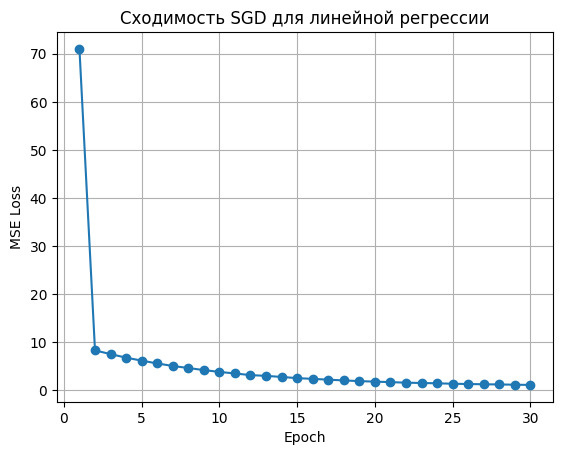

In [1]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
n_samples = 100
x = np.random.rand(n_samples) * 10 
epsilon = np.random.randn(n_samples)  
y = 4 * x + 6 + epsilon 


w = 0.0
b = 0.0
lr = 0.001 
epochs = 30

loss_history = []

#Обучение SGD
for epoch in range(epochs):
    epoch_loss = 0
    # Перемешивание индексов для стохастичности
    indices = np.random.permutation(n_samples)
    for i in indices:
        xi = x[i]
        yi = y[i]
        
        y_pred = w * xi + b
        error = y_pred - yi
        
        # Градиенты для MSE одного примера
        dw = 2 * error * xi
        db = 2 * error
        
        # Обновление параметров
        w -= lr * dw
        b -= lr * db
        
        epoch_loss += error**2
    
    # Средняя ошибка на эпоху
    avg_loss = epoch_loss / n_samples
    loss_history.append(avg_loss)


final_loss = loss_history[-1]
print(f"Финальные параметры: w = {w:.4f}, b = {b:.4f}")
print(f"Финальный loss: {final_loss:.6f}")


plt.plot(range(1, epochs+1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Сходимость SGD для линейной регрессии")
plt.grid(True)
plt.show()